
# Numerical Differentiation as an Inverse Problem

**Course 02624**
*(Kim Knudsen, 2026)*

## The problem

We are given (noisy) data $y$ and we want to recover $x$ from the relation

$$
y'(t) = x(t), \qquad y(0) = 0 .
$$

Equivalently, we are seeking the solution to

$$
Kx(t) = y(t), \qquad Kx(t) = \int_0^t x(s)\, ds.
$$

The **forward operator** (integration) defines thorugh $K$ a well-posed problem, say in $L^2(0,1)$.

## Discretization

We discretize $K$ using a quadrature rule on a uniform grid, and sample $Kx(t)$ and $y(t)$ on another grid shifted $h.$ 


### Setup

Import the numerical/plotting libraries we need (`numpy` for arrays and linear algebra,
`matplotlib` for plotting).

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)  # reproducible noise


### Grid

We discretize $[0,1)$ into $N$ equal subintervals of width $h = 1/N$, with grid points

\begin{align*}
s_i &= i\,h, \qquad i = 0,1,\dots,N-1;\\
t_j &= s_i + h.
\end{align*}


In [3]:
# Initialization of grid
N = 64
h = 1 / N
svec = np.arange(0, 1, h).reshape(-1, 1)   # s_i = i*h,  i = 0,...,N-1
tvec = svec + h

### Matrix approximation

We approximate the integral

$$
y(t_{i+1}) = \int_0^{t_{i+1}} x(s)\,ds = \sum_{j=0}^{i} \int_{t_j}^{t_{j+1}} x(s)\,ds
\approx h \sum_{j=0}^{i} x(s_j)
$$

using the **left-endpoint (rectangle) quadrature rule** on each subinterval. Written as a linear
map $\mathbf{y} = A\mathbf{x}$, this is

$$
A = h
\begin{pmatrix}
1 & 0 & \cdots & 0 \\
1 & 1 & \cdots & 0 \\
\vdots & & \ddots & \vdots \\
1 & 1 & \cdots & 1
\end{pmatrix}
\in \mathbb{R}^{N\times N}.
$$


In [4]:
# Matrix A implements left point quadrature rule
A = np.tril(np.ones((N, N))) * h

# Let's see the rank of A
print(f'rank(A) = {np.linalg.matrix_rank(A)} / {A.shape[0]}')


rank(A) = 64 / 64


## True solution $x$ and data $y$

We use the **true solution pair** (so we can check numerical results against an exact answer):

$$
x(s) = e^{-s}(1-s), \qquad y(t) = t\,e^{-t},
$$

which indeed satisfy $y'(t) = x(t)$, $y(0)=0$.

### Inspect the functions

Plot the true $x(s)$, and compare the quadrature-generated data `yvec` against the exact $y(s+h)$
on the shifted grid, to confirm the discretization of $K$ is accurate.

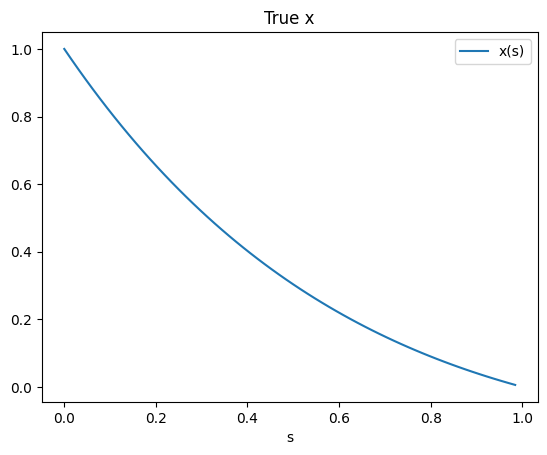

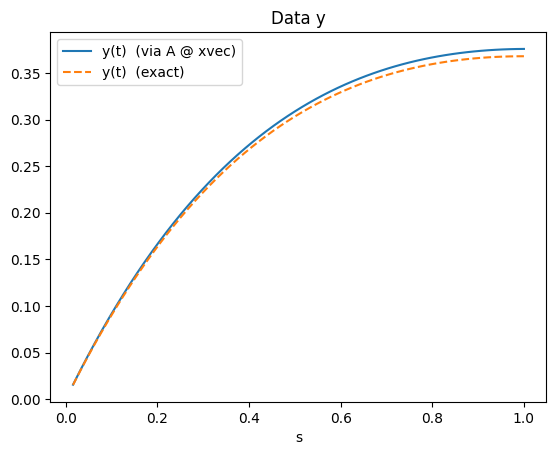

In [5]:
# True solution x and data y
y = lambda s: s * np.exp(-s)
x = lambda s: np.exp(-s) * (1 - s)

# Discretization of x and y
xvec = x(svec)
A = np.tril(np.ones((N, N))) * h
yvec = A @ xvec


fig1 = plt.figure(1)
plt.plot(svec, xvec)
plt.title('True x')
plt.legend(['x(s)'])
plt.xlabel('s')
plt.show()

fig2 = plt.figure(2)
plt.plot(tvec, yvec, label='y(t)  (via A @ xvec)')
plt.plot(tvec, y(tvec), '--', label='y(t)  (exact)')
plt.title('Data y')
plt.legend()
plt.xlabel('s')
plt.show()


## Add noise

Real data is noisy. We perturb the exact data with additive Gaussian noise,

$$
y^{\delta} = y + d, \qquad d \sim \mathcal{N}(0,\sigma^2 I),
$$

and quantify the noise level relative to the data as

$$
\text{noise level} = \frac{\lVert d\rVert_2}{\lVert y \rVert_2}.
$$


In [6]:
# Add noise
d = 0.005 * rng.standard_normal((N, 1))
yvecnoise = yvec + d
noiselevel = np.linalg.norm(d) / np.linalg.norm(yvec)
print(f'noise level = {noiselevel:.4f}')


noise level = 0.0157


## Naïve inversion

We now solve the discretized inverse problem **naively**, by directly inverting the (invertible,
triangular) matrix $A$:

$$
\hat{\mathbf{x}} = A^{-1} \mathbf{y}^{\delta}.
$$

Because differentiation (the inverse of integration) is unbounded / ill-posed, small noise $\eta$
in the data can be amplified into large errors in $\hat{\mathbf{x}}$ — this is the numerical
manifestation of ill-posedness, and is what the rest of the course addresses (e.g. via
regularization). We measure the reconstruction quality with the relative error

$$
\text{relative error} = \frac{\lVert x - \hat{x} \rVert_2}{\lVert x \rVert_2}.
$$


In [7]:
# Solve naively the inverse problem
xvecrecon = np.linalg.solve(A, yvecnoise)

# Calculate relative error in the result
relerror = np.linalg.norm(xvec - xvecrecon) / np.linalg.norm(xvec)
print(f'relative error = {relerror:.4f}')


relative error = 0.7821


## Inspect results

Compare the noisy data to the exact data, and the naive reconstruction $\hat{x}$ to the true $x$.

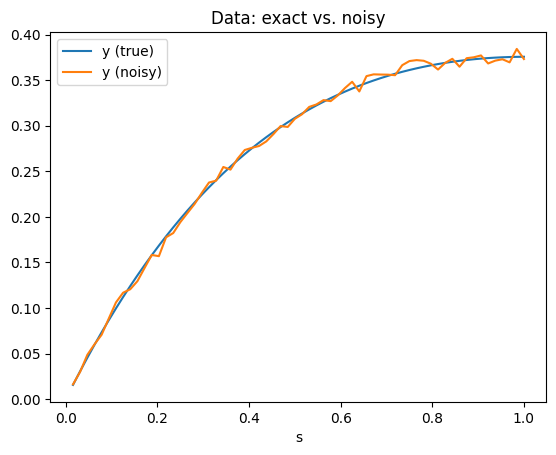

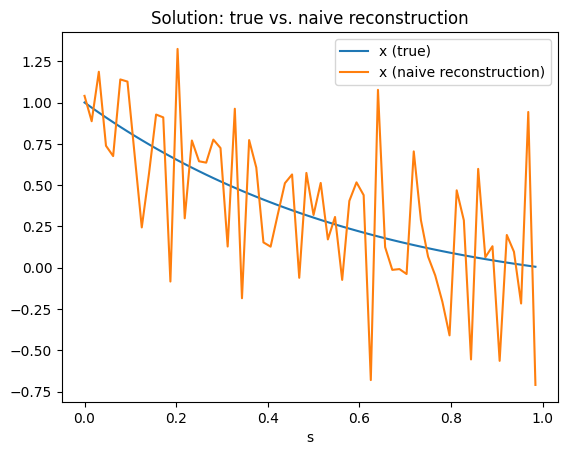

In [8]:
fig3 = plt.figure(3)
plt.plot(tvec, yvec, label='y (true)')
plt.plot(tvec, yvecnoise, label='y (noisy)')
plt.title('Data: exact vs. noisy')
plt.legend()
plt.xlabel('s')
plt.show()

fig4 = plt.figure(4)
plt.plot(svec, xvec, label='x (true)')
plt.plot(svec, xvecrecon, label='x (naive reconstruction)')
plt.title('Solution: true vs. naive reconstruction')
plt.legend()
plt.xlabel('s')
plt.show()


## Singular Value Decomposition (SVD)

To see *why* the naive inversion blew up, look at the SVD $A = U\Sigma V^T$. The decay rate of the singular values $\sigma_i$ reflects how strongly $A$ smooths — and hence how strongly $A^{-1}$ amplifies noise.

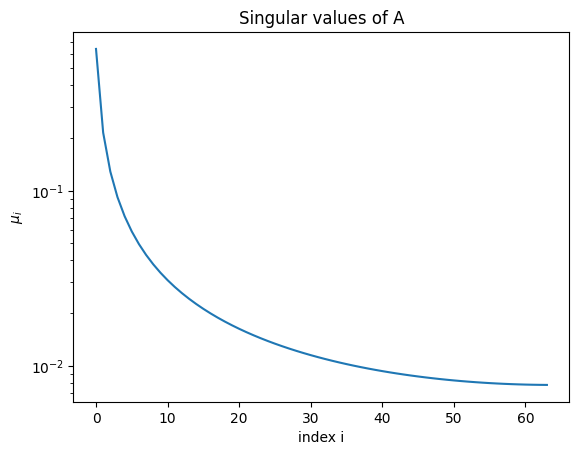

In [9]:
# Singular Value Decomposition of A
U, s, Vt = np.linalg.svd(A)

fig5 = plt.figure(5)
plt.semilogy(s)
plt.title('Singular values of A')
plt.xlabel('index i')
plt.ylabel(r'$\mu_i$')
plt.show()


## Picard plot

The **discrete Picard condition** requires the data coefficients $|u_i^T y^\delta|$ to decay (on average) at least as fast as $\mu_i$. Plotting $\mu_i$, $|u_i^T y^\delta|$, and the ratio $|u_i^T y^\delta|/\mu_i$ together shows exactly where noise takes over.

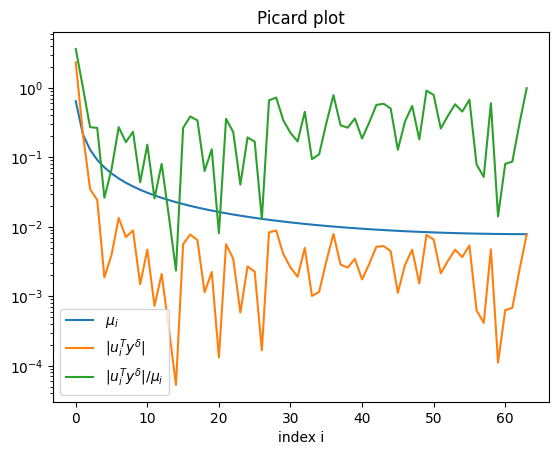

In [10]:
# Picard plot: sigma_i, |u_i^T y^delta|, and the SVD coefficients |u_i^T y^delta| / sigma_i
utb = np.abs(U.T @ yvecnoise).flatten()
coeffs = utb / s

fig6 = plt.figure(6)
plt.semilogy(s, label=r'$\mu_i$')
plt.semilogy(utb, label=r'$|u_i^T y^\delta|$')
plt.semilogy(coeffs, label=r'$|u_i^T y^\delta| / \mu_i$')
plt.title('Picard plot')
plt.xlabel('index i')
plt.legend()
plt.show()


## Truncated SVD (TSVD)

A simple regularization: keep only the first $k$ SVD components, before the noise floor is reached, and drop the rest:

$$
x_k = \sum_{\mu_i > \alpha} \frac{u_i^T y^\delta}{\mu_i}\, v_i .
$$

This removes exactly the noise-dominated, high-index terms responsible for the blow-up seen above.

In [11]:
def tsvd(U, s, Vt, b, k):
    """Truncated SVD solution using the first k singular components."""
    coeffs = (U[:, :k].T @ b) / s[:k, None]
    return Vt[:k, :].T @ coeffs


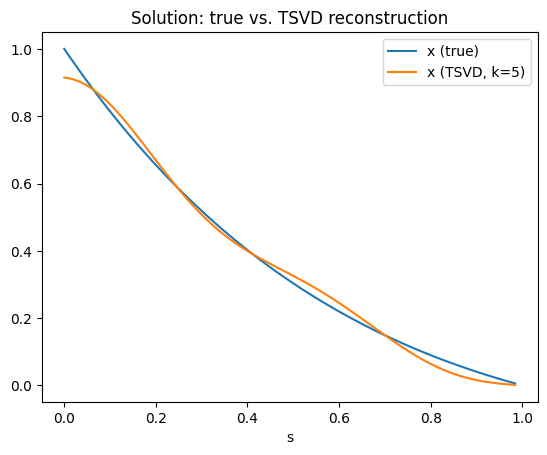

In [15]:
# Compare the TSVD reconstruction at k to true x
k = 5
xvecrecon_tsvd = tsvd(U, s, Vt, yvecnoise, k)

fig8 = plt.figure(8)
plt.plot(svec, xvec, label='x (true)')
plt.plot(svec, xvecrecon_tsvd, label=f'x (TSVD, k={k})')
plt.title('Solution: true vs. TSVD reconstruction')
plt.legend()
plt.xlabel('s')
plt.show()
